# Spectral density as a function of $4t$ for fixed $\mu$ #

In [2]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import h5py
import numpy as np
import class_utils as class_utils
import matplotlib
from class_grid import Grid
from class_params import Params
from class_groundstate import groundstate
from class_excitations import excitations
from class_vertices import vertices
from class_perturbation import perturbative
from class_self_energy import Self_Energy
from class_io import IO
from class_plotting import plot2D, plot_cns, plot_omega0
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from scipy import interpolate

In [101]:
# conversion between MC and QGW 
# MC data in MI at UIB = 1.5 U
# 0.75 value is interpolate for UIB 1p5
# all values are interpolated for UIB -1p5
MC_to_QGW = 0.1292 / ( 4 * 0.045) # qgw / MC


#hopping
t_Matija_MC= np.array([0.01,0.015,0.02,0.025,0.03,0.035,0.04,0.045,0.05,0.055,0.06,0.065,0.07,0.075])
#energies
Ep_Matija_UIB_1p5 = np.array([0.9564626057,0.9336809943,0.9100511069,0.8853755808,0.8590815707,0.8309053212,0.7991644585,0.762848257,0.7190450017,0.6667375136,0.6221272652,0.6166042472,0.6400243702,0.6655410675])
Ep_Matija_UIB_1p0 = np.array([0.9587093145,0.9364059961,0.913219459,0.8885494595,0.8621197323,0.8333712351,0.8009601262,0.7626794911,0.7159211234,0.659379226,0.6060795453,0.5873374183,0.5949207444,0.6090832515])
Ep_Matija_UIB_0p5 = np.array([0.4994887388,0.4988958469,0.498083353,0.4970997236,0.4959171713,0.4946263455,0.4931991863,0.491692903,0.4888610017,0.480440858,0.4587387917,0.4353459947,0.4251578658,0.4210527202])
Ep_Matija_UIB_m0p5 = np.array([-0.5005101622,-0.5011031536,-0.5019059981,-0.5028779997,-0.5040446895,-0.5053021229,-0.5067590036,-0.5083781865,-0.5104402917,-0.5164005131,-0.5317570535,-0.5511854567,-0.562564214,-0.5680343593])
Ep_Matija_UIB_m1p0 = np.array([-1.017345291,-1.026549991,-1.035636545,-1.046563127,-1.058126019,-1.072136958,-1.090599545,-1.1170411,-1.157332996,-1.217675254,-1.286872403,-1.329275248,-1.342824562,-1.346340987])
Ep_Matija_UIB_m1p5 = np.array([-2.005046061,-2.010877559,-2.0188552,-2.029554248,-2.04333265,-2.060918635,-2.084478325,-2.116223715,-2.163363013,-2.233592827,-2.315400502,-2.363951663,-2.378549341,-2.378937433])
#error bars
Ep_Error_UIB_m1p5 = np.array([0.0002538392296,0.0003353137729,0.000288825283,0.0002573811918,0.0005067805106,0.0007948796509,0.001792606071,0.004244092211,0.007089050072,0.007603642652,0.002495617669,0.002660506845,0.006036178469,0.008733482878])
Ep_Error_UIB_m1p0 = np.array([0.0006097454727,0.001070603418,0.001755243756,0.001818520564,0.002319438696,0.001956422859,0.0004183186896,0.002343735575,0.005684065265,0.005855149478,0.000393835455,0.0001088368206,0.003753130631,0.005289380022])
Ep_Error_UIB_m0p5 = np.array([5.26E-06,4.17E-05,8.45E-05,0.0001569480054,0.0003008712359,0.0005406478398,0.0008602355436,0.001189879433,0.0007998321263,0.0004891497351,0.0009730377156,0.0002539785821,0.0006714935397,0.00131688987])
Ep_Error_UIB_0p5 = np.array([3.85E-06,3.88E-05,9.67E-05,0.0001777824868,0.0003803892146,0.0006995051929,0.001048335879,0.001264652607,0.0004758088953,0.001589771265,0.001180884721,0.0003777081827,0.001060725446,0.001648476215])
Ep_Error_UIB_1p0 = np.array([0.0001171796678,2.96E-05,0.0001341764073,0.0002091340446,0.0006056439733,0.001286065702,0.002518851405,0.004483749766,0.007391572799,0.005535996016,0.0006795253077,0.003090237587,0.00719487393,0.007826187606])
Ep_Error_UIB_1p5 = np.array([0.0008020356698,0.001168604462,0.001729680543,0.00226964684,0.003108692815,0.004321065192,0.005975374025,0.008212387916,0.009965181068,0.008530746948,0.00401867947,0.006316677637,0.01054419804,0.01093456396])
#conversion
t_Matija_QGW = MC_to_QGW * t_Matija_MC   
dJUs_Matija_QGW = 4 * t_Matija_QGW

In [102]:
config_path = "config.yml" 

output_dir = class_utils.create_output_dir()
config = class_utils.read_config(config_path)

# load fixed density data 
dJUs_grid = np.loadtxt('./ragheed_data/dJU_values_nqcorr_1.csv',delimiter=',',skiprows=1).transpose()
muUs_grid = np.loadtxt('./ragheed_data/muU_values_nqcorr_1.csv',delimiter=',',skiprows=1)

# create interpolating function
f = interpolate.interp1d(dJUs_grid, muUs_grid)

Lx = config["grid"]["Lx"]
Ly = config["grid"]["Ly"]
cutoff = config["physics"]["cutoff"]
N = config["physics"]["N"]
UIB = config["physics"]["UIB"]
M = Lx * Ly

grid = Grid(Lx, Ly)

num_en = 200 # 100 gets pretty good resolution.  takes at least an hour then.
num_dJU = 200 # 100
dJU_max = 0.2154#0.2154
dJU_min = 0.02871#0.1292
en_vector = np.linspace(0, 2, num_en)#0.001,0.5,num_en) #0.001, 0.5,num_en)
dJUs = np.linspace(dJU_min, dJU_max, num_dJU)
muUs = f(dJUs)

In [143]:
### RUN THIS BLOCK IF LOADING FROM A FILE. ###

input("confirm data is to be loaded.")

filename = f'./data/self_consistent_t/mean_field/t_scan/qmcorr_n_1p0/UIB_1.5_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5'
#UIB_-0.2_Mu_0.20_M_100_N_7_num_en_100_Lower_num_dJU_100_dJU_max_0.5
with h5py.File(filename, 'r') as f:
    en_vector = f['en_vector'][:]
    omega0s = f['omega0s'][:]
    omega1s = f['omega1s'][:]
    omega2s = f['omega2s'][:]
    
    T11 = []
    T12 = []
    T21 = []
    T22 = []
    T22_F = []
    SE_SI = []

    for count, dJU in enumerate(dJUs):
        group = f[f'dJU_{dJU}']
        T11.append(group['T11'][:])
        T12.append(group['T12'][:])
        T21.append(group['T21'][:])
        T22.append(group['T22'][:])
        T22_F.append(group['T22_SE'][:])
        SE_SI.append(group['SE_SI'][:])

confirm data is to be loaded. 


In [4]:
# run this block if you are making the data for the first time

input("confirm that you would like to make the data for the first time")

omega0s = np.zeros(len(dJUs))
omega1s = np.zeros(len(dJUs))
omega2s = np.zeros(len(dJUs))

SE = np.zeros((7, len(en_vector)), dtype=np.complex128)  #7 rows for each contribution, num_en columns ##V: why 7?


#V:  Add poles to this plot!!!
T11 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T12 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T21 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T22 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T22_F = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
SE_SI = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)

for count, dJU in enumerate(dJUs):
    muU = muUs[count]
    print(count,dJU,muU)
    params = Params(N, dJU, muU, UIB, cutoff)
    gs = groundstate(params)
    cns = gs.cns()
    n0 = gs.n0(cns)
    psi0 = gs.psi0(cns)
    exc = excitations(grid, params, gs, cns)
    uks, vks, omegaklambda = exc.calculate_matrices()
    verts = vertices(grid, gs, uks, vks, cns, n0)
    pert = perturbative(grid, params, verts, omegaklambda)
    Pert_Energy = pert.perturbative_energy(n0)
    omega0s[count] = Pert_Energy[0]
    omega1s[count] = Pert_Energy[1]
    omega2s[count] = Pert_Energy[2]
    print(n0, pert.sigma0(n0) / UIB)

    for epol_ind in range(len(en_vector)):
        # # Non-self consistent
        # Epol_NSC = en_vector[epol_ind] - UIB
        # self_energy = Self_Energy(Epol_NSC, grid, params, verts, omegaklambda)
        # output_NSC = self_energy.calculate_self_energy()
        # # Self consistent
        Epol_SC = en_vector[epol_ind] - UIB #output_NSC[6]
        self_energy = Self_Energy(Epol_SC, grid, params, verts, omegaklambda)
        output_SC = self_energy.calculate_self_energy()
        SE[:, epol_ind] = output_SC
    #The zeroth element is the full self energy minus w, used for finding the zero crossings.
    T11[count, :] = SE[1, :]
    T12[count, :] = SE[2, :]
    T21[count, :] = SE[3, :]
    T22[count, :] = SE[4, :]
    T22_F[count, :] = SE[5, :]
    SE_SI[count, :] = SE[6, :]

confirm that you would like to make the data for the first time 


0 0.02871 0.41421356237309515
1.0 1.0
1 0.029648140703517588 0.41421356237309515
1.0 1.0
2 0.030586281407035176 0.41421356237309515
1.0 1.0
3 0.031524422110552765 0.41421356237309515
1.0 1.0
4 0.03246256281407035 0.41421356237309515
1.0 1.0
5 0.03340070351758794 0.41421356237309515
1.0 1.0
6 0.03433884422110553 0.41421356237309515
1.0 1.0
7 0.03527698492462311 0.41421356237309515
1.0 1.0
8 0.03621512562814071 0.41421356237309515
1.0 1.0
9 0.03715326633165829 0.41421356237309515
1.0 1.0
10 0.038091407035175884 0.41421356237309515
1.0 1.0
11 0.039029547738693465 0.41421356237309515
1.0 1.0
12 0.039967688442211054 0.41421356237309515
1.0 1.0
13 0.04090582914572864 0.41421356237309515
1.0 1.0
14 0.04184396984924623 0.41421356237309515
1.0 1.0
15 0.04278211055276382 0.41421356237309515
1.0 1.0
16 0.04372025125628141 0.41421356237309515
1.0 1.0
17 0.044658391959798996 0.41421356237309515
1.0 1.0
18 0.045596532663316584 0.41421356237309515
1.0 1.0
19 0.04653467336683417 0.41421356237309515
1.

In [144]:
# construct the spectral function and T-matrices 
SpectralFuncs = np.zeros((len(dJUs), len(en_vector)), dtype = float)
Sigma = np.zeros((len(dJUs), len(en_vector)),dtype=np.complex128)
Sigma00 = np.zeros((len(dJUs), len(en_vector)),dtype=np.complex128)
dOmega = en_vector[1] - en_vector[0]
eta = 0.01  #0.01# 

#
for count in range(0, len(dJUs)):
    SpectralFuncs[count, :] = dOmega * (-2) * np.imag(1./(en_vector - SE_SI[count] + 1j * eta))
    Sigma[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) +  T22_F[count]
    Sigma00[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) 


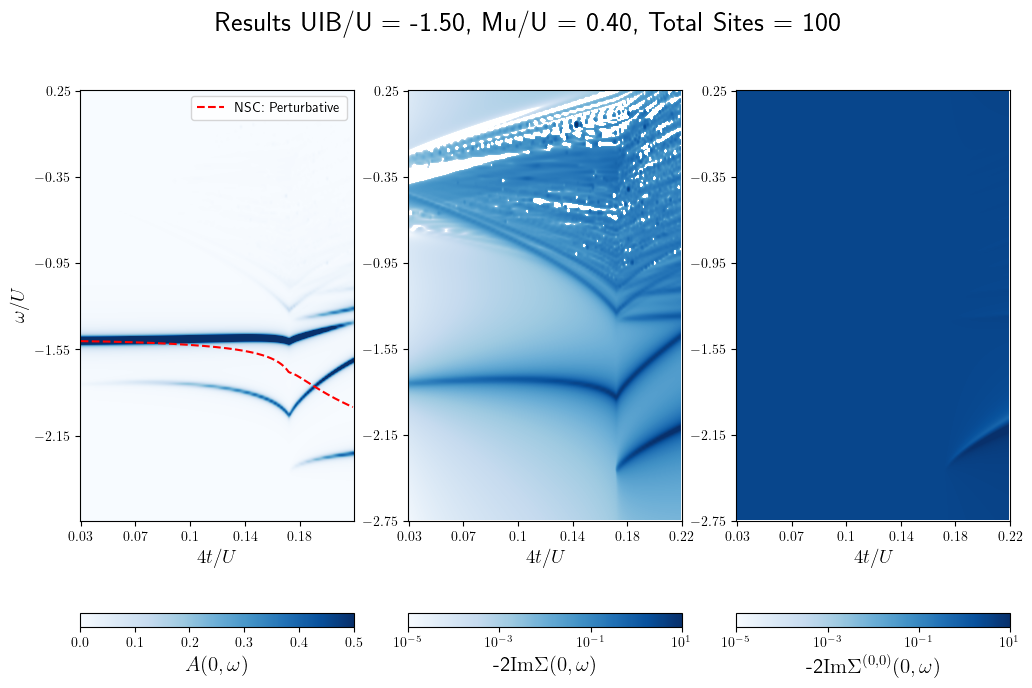

In [10]:
plt.rcParams['text.usetex'] = True


# Rotate the image by -90 degrees
SpectralFuncs_rot = np.rot90(SpectralFuncs, 1)
Sigma_rot = np.rot90(Sigma, 1)
Sigma00_rot = np.rot90(Sigma00, 1)


fig, (ax1, ax2, ax3) = plt.subplots(ncols = 3, figsize = (12,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 'auto'
interp = 'Bicubic'
color_map = 'Blues'
im1 = ax1.imshow( np.abs(SpectralFuncs_rot), interpolation = interp, cmap = color_map, aspect = aspect_ratio)#, norm=matplotlib.colors.LogNorm())
im2 = ax2.imshow(-2 * np.imag(Sigma_rot), interpolation = interp,cmap = color_map, aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())
im3 = ax3.imshow(2 * np.abs(Sigma00_rot), interpolation = interp,cmap = color_map, aspect = aspect_ratio,norm=matplotlib.colors.LogNorm())


# Select a subset of dJUs and en_vector for the ticks
num_xticks = 6
num_yticks = 6

xticks = np.linspace(0, SpectralFuncs_rot.shape[1], num_xticks, endpoint=True, dtype=int)
yticks = np.linspace(0, SpectralFuncs_rot.shape[0], num_yticks, endpoint=True, dtype=int)

xticklabels = np.round(np.linspace(min(dJUs), max(dJUs), num_xticks), 2)
yticklabels = np.round(np.linspace(max(en_vector), min(en_vector), num_yticks), 2)

# Format the labels in LaTeX
xticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in xticklabels]
yticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in yticklabels]

ax1.set_xticks(xticks)
ax1.set_yticks(yticks)
ax2.set_xticks(xticks)
ax2.set_yticks(yticks)
ax3.set_xticks(xticks)
ax3.set_yticks(yticks)
ax1.set_xticklabels(xticklabels)
ax1.set_yticklabels(yticklabels)
ax2.set_xticklabels(xticklabels)
ax2.set_yticklabels(yticklabels)
ax3.set_xticklabels(xticklabels)
ax3.set_yticklabels(yticklabels)
ax1.set_xlabel(r'$4t/U$', fontsize=14)
ax2.set_xlabel(r'$4t/U$', fontsize=14)
ax3.set_xlabel(r'$4t/U$', fontsize=14)
ax1.set_ylabel(r'$\omega/U$', fontsize=14)

cb1 = plt.colorbar(im1,orientation="horizontal")
cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
cb2 = plt.colorbar(im2,orientation="horizontal")
cb2.set_label(label = "-2$\mathrm{Im\Sigma(0,\omega)}$",size=15,weight='bold')
cb3 = plt.colorbar(im3,orientation="horizontal")
cb3.set_label(label = "-2$\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')
im1.set_clim(0, 0.5)
im2.set_clim(1e-5, 1e1)
im3.set_clim(1e-5, 1e1)



X, Y = np.meshgrid(dJUs, omega0s + omega1s + omega2s)
# ax2 = ax.twinx()
# Transform the y-coordinates of the plot to match the image coordinates
plot_x = np.interp(dJUs, (dJUs.min(), dJUs.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(omega0s + omega1s + omega2s, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
#plot_y_pole = SpectralFuncs_rot.shape[0] - 1 - np.interp(pol_w, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))


# Overlay the plot on top of the imshow figure
ax1.plot(plot_x, plot_y, linestyle='--', label='NSC:  Perturbative', color='red', linewidth=1.5)
#ax1.plot(plot_x[20:-1], plot_y_pole[20:-1], linestyle = ':', label='Lowest Pole T-matrix', color='green', linewidth=2)
#ax2.plot(plot_x[20:-1], plot_y_pole[20:-1], linestyle = ':', label='Lowest Pole T-matrix', color='green', linewidth=2)
ax1.legend()
#ax2.legend()
fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Mu/U = {muU:0.2f}, Total Sites = {M}", fontsize = 20)
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
/var/folders/2l/tnyqm1055x7gxkrlkswtl5xc0000gn/T/ipykernel_6654/3806390307.py:21: SyntaxWarning: invalid escape sequence '\o'
  cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')


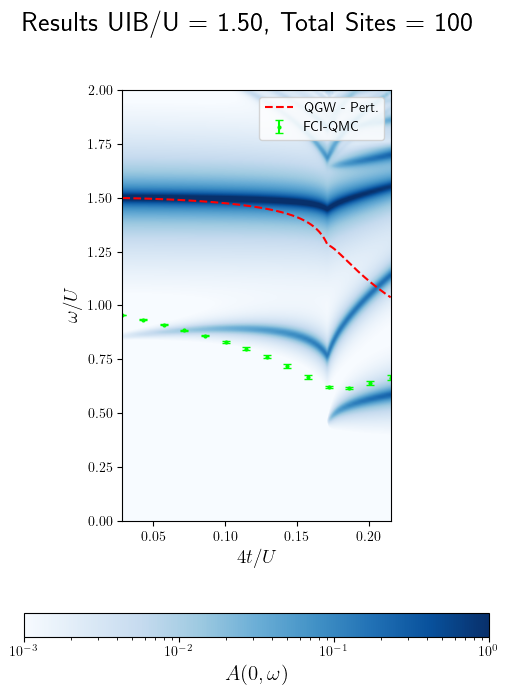

In [145]:

plt.rcParams['text.usetex'] = True

# Rotate the image by -90 degrees
SpectralFuncs_rot = np.rot90(SpectralFuncs, 1)


fig, ax1 = plt.subplots(ncols = 1, figsize = (6,8)) # (6,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 0.15#0.1#'auto' # 0.15 for UIB >0, 0.1 for UIB < 0
color_map = 'Blues'
interp = 'bicubic'
extent = [min(dJUs), max(dJUs),min(en_vector), max(en_vector) ]
im1 = ax1.imshow(np.abs(SpectralFuncs_rot), interpolation = interp, cmap=color_map, aspect = aspect_ratio, extent = extent, norm=matplotlib.colors.LogNorm())

ax1.set_xlabel(r'$4t/U$', fontsize=14)
ax1.set_ylabel(r'$\omega/U$', fontsize=14)

cb1 = plt.colorbar(im1,orientation="horizontal")
cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
im1.set_clim(1e-3,1e0)


idx = np.searchsorted(en_vector, 0, side="left") # find \omega = 0

UIB = 1.5
# # # plot the extrapolated MC data.
Ep_M = Ep_Matija_UIB_1p5
Errors_M = Ep_Error_UIB_1p5
dJUs_M = dJUs_Matija_QGW
plot_x = dJUs_M
plot_y = Ep_M
plot_y_errors = Errors_M
#ax1.scatter(plot_x,plot_y)
ax1.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = '.',markersize = 4,linestyle = 'none',capsize = 3, label='FCI-QMC', color='lime')

#plot perturbative result
plot_x = dJUs
plot_y = omega0s + omega1s + omega2s
fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
ax1.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)


ax1.legend()

plt.show()

In [146]:
## Save the figure 
filename = f'../figs/self_consistent_t/mean_field/t_scan/qmcorr_n_1p0/error_bars/UIB_{UIB}_Mu_M_{grid.M}_N_{N}_num_en_{num_en}_num_dJU_{num_dJU}_dJU_max_{dJU_max}_eta_{eta}_cutoff_{cutoff}_full_crossover_slim.pdf'
fig.savefig(filename, dpi=300, bbox_inches='tight')

In [35]:
# this returns the array indices
SpectralFuncs_rot.shape[0] - 1 - np.interp(Errors_M, [en_vector.min(), en_vector.max()], [0, SpectralFuncs_rot.shape[0]-1])

array([182.43350467, 182.43890915, 182.43582541, 182.43373962,
       182.45028311, 182.46939368, 182.5355762 , 182.69819145,
       182.88690699, 182.92104163, 182.58220931, 182.59314695,
       182.81706651, 182.9959877 ])

In [28]:
print(Errors_M)
print
print(plot_y)

[0.00025384 0.00033531 0.00028883 0.00025738 0.00050678 0.00079488
 0.00179261 0.00424409 0.00708905 0.00760364 0.00249562 0.00266051
 0.00603618 0.00873348]
[116.2043176  116.21236765 116.22068373 116.22926705 116.23811886
 116.24724054 116.2566335  116.26629924 116.27623935 116.28645548
 116.29694938 116.30772286 116.31877784 116.3301163  116.34174033
 116.35365209 116.36585383 116.3783479  116.39113675 116.40422291
 116.41760902 116.43129781 116.44529213 116.45959492 116.47420922
 116.48913819 116.50438513 116.5199534  116.53584652 116.55206812
 116.56862196 116.58551192 116.60274202 116.6203164  116.63823936
 116.65651534 116.67514893 116.69414485 116.713508   116.73324344
 116.7533564  116.77385227 116.79473663 116.81601523 116.83769403
 116.85977918 116.88227702 116.90519412 116.92853725 116.95231343
 116.97652989 117.0011941  117.02631382 117.05189702 117.07795198
 117.10448723 117.13151162 117.15903429 117.18706469 117.21561261
 117.24468818 117.27430187 117.30446455 117.335187

In [8]:
# Save the data

# Code to save results for different UIBs
#filename = f'./data/self_consistent_t/mean_field/t_scan/qmcorr_n_1p0/UIB_{UIB}_M_{grid.M}_N_{N}_num_en_{num_en}_num_dJU_{num_dJU}_dJU_max_{dJU_max}_eta_{eta}_cutoff_{cutoff}_full_crossover.hdf5'



with h5py.File(filename, 'w') as f:
    f.create_dataset('UIBs', data=dJUs)
    f.create_dataset('en_vector', data=en_vector)
    f.create_dataset('omega0s', data=omega0s)
    f.create_dataset('omega1s', data=omega1s)
    f.create_dataset('omega2s', data=omega2s)
    for i, dJU in enumerate(dJUs):
    # Create a group for this dJU value
        group = f.create_group(f'dJU_{dJU}')

        # Store the arrays in this group
        group.create_dataset('T11', data=T11[i, :])
        group.create_dataset('T12', data=T12[i, :])
        group.create_dataset('T21', data=T21[i, :])
        group.create_dataset('T22', data=T22[i, :])
        group.create_dataset('T22_SE', data=T22_F[i, :])
        group.create_dataset('SE_SI', data=SE_SI[i, :])
    

    # Create attributes for your parameters
    f.attrs['UIB'] = UIB
    f.attrs['muU'] = muU
    f.attrs['Lx'] = grid.Lx
    f.attrs['Ly'] = grid.Ly
    f.attrs['N'] = N


    UIBs = f['UIBs'][:]
    en_vector = f['en_vector'][:]
    omega0s = f['omega0s'][:]
    omega1s = f['omega1s'][:]
    omega2s = f['omega2s'][:]

    T11 = []
    T12 = []
    T21 = []
    T22 = []
    T22_SE = []
    SE_SI = []

    for count, dJU in enumerate(dJUs):
        group = f[f'dJU_{dJU}']
        T11.append(group['T11'][:])
        T12.append(group['T12'][:])
        T21.append(group['T21'][:])
        T22.append(group['T22'][:])
        T22_SE.append(group['T22_SE'][:])
        SE_SI.append(group['SE_SI'][:])